<a href="https://colab.research.google.com/github/alkhurayjah/Unit3_Project/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries and dataset downloads

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set_style("whitegrid")

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaykhaaldawsari/jadarat-cleaned-data-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'jadarat-cleaned-data-csv' dataset.
Path to dataset files: /kaggle/input/jadarat-cleaned-data-csv


In [28]:
df = pd.read_csv( path + "/processed_dataset.csv")

### Data Dictionary (Feature Metadata)

| Column Name | Symbol / Code | Explanation |
| :--- | :--- | :--- |
| **job_title** | Simplified Roles | Core job roles mapped to predefined categories (e.g., Accountant, Technician). |
| **job_date** | Dates (Gregorian) | Date the job was posted. |
| **comp_name** | AS-IS | The company name remains as originally provided in the dataset. |
| **comp_type** | 1, 0 | **1** - Private, **0** - Semi-Governmental. |
| **comp_size** | MA, MB, MC, etc. | Indicates the company size: **MA** - Medium A, **SB** - Small B, etc. |
| **eco_activity** | Various Sectors | Generalized industry sector such as Trade and Retail, Healthcare. |
| **region** | Names (e.g., Eastern) | Translated and normalized Saudi regions (e.g., Eastern Province). |
| **city** | Translated Names | Translated and normalized city names (e.g., AD DAMMAM, RIYADH). |
| **contract** | 1, 0 | **1** - Full-time, **0** - Remote. |
| **benefits** | 1, 0 | **1** - Benefits offered, **0** - No benefits. |
| **positions** | Numbers (e.g., 10) | Number of positions available for the job. |
| **exper** | Numeric values | Years of experience required, converted to integers (e.g., 0, 2). |
| **gender** | 0, 1, 2 | **0** - Male, **1** - Female, **2** - Both. |
| **Salary** | Numeric values | Represents the monthly salary in **SAR**. |

---



---



#First data preview

In [29]:
df.head()

,job_title,job_date,comp_name,comp_type,comp_size,eco_activity,region,city,benefits,contract,positions,exper,gender,Salary
0,Secretary,2022-10-01,مؤسسة دمك للمقاولات العامة,1,SB,Construction and Real Estate,Eastern,BUQAYQ,0,1,1,0,1,4000.0
1,Salesperson,2022-10-03,شركة محمد سراج عطار وأخويه,1,SB,Trade and Retail,Makkah,JEDDAH,1,1,3,0,0,4000.0
2,Receptionist,2022-10-08,مركز شار لطب الاسنان,1,MA,Trade and Retail,Makkah,JEDDAH,1,1,2,4,1,4000.0
3,Accountant,2022-10-12,شركة اسواق بساتين القصيم,1,MB,Trade and Retail,Riyadh,AR RIYADH,1,1,10,0,2,4000.0
4,Secretary,2022-10-13,شركة السبائك الذهبية للمعادن الثمينة,1,SA,Trade and Retail,Makkah,JEDDAH,1,1,1,2,1,5000.0


In [30]:
df.shape

(1470, 14)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_title     1470 non-null   object 
 1   job_date      1470 non-null   object 
 2   comp_name     1470 non-null   object 
 3   comp_type     1470 non-null   int64  
 4   comp_size     1470 non-null   object 
 5   eco_activity  1470 non-null   object 
 6   region        1470 non-null   object 
 7   city          1470 non-null   object 
 8   benefits      1470 non-null   int64  
 9   contract      1470 non-null   int64  
 10  positions     1470 non-null   int64  
 11  exper         1470 non-null   int64  
 12  gender        1470 non-null   int64  
 13  Salary        1470 non-null   float64
dtypes: float64(1), int64(6), object(7)
memory usage: 160.9+ KB


In [32]:
df.duplicated().sum()

np.int64(83)

In [33]:
df.isnull().sum()

,0
job_title,0
job_date,0
comp_name,0
comp_type,0
comp_size,0
eco_activity,0
region,0
city,0
benefits,0
contract,0


In [34]:
df.describe()

,comp_type,benefits,contract,positions,exper,gender,Salary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.996599,0.265306,0.985034,2.938776,1.278912,1.072789,5294.650340
std,0.058242,0.441646,0.121458,6.400864,1.879568,0.849142,2296.926479
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3000.000000
25%,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,4000.000000
50%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,4500.000000
75%,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,6000.000000
max,1.000000,1.000000,1.000000,50.000000,12.000000,2.000000,35000.000000


In [35]:
print(df.nunique())

job_title        44
job_date         90
comp_name       886
comp_type         2
comp_size         8
eco_activity     13
region           13
city            114
benefits          2
contract          2
positions        16
exper             6
gender            3
Salary           85
dtype: int64


### 1. Data Description Insights
By utilizing the `describe()` function, we extracted valuable preliminary insights regarding the nature of the posted jobs:

* **Salary:** The average offered salary is **5,294 SAR**, starting from a minimum of **3,000 SAR** and reaching a maximum of **35,000 SAR**. We can observe that 50% of the jobs (the median) offer a salary of 4,500 SAR or less, indicating that most jobs target entry-level to mid-level positions.
* **Experience (`exper`):** The average required experience is **1.27 years**. Interestingly, 50% of the jobs (the median) do not require any prior experience (**0 years**), making this platform an excellent environment for fresh graduates.
* **Vacancies (`positions`):** On average, each job posting announces around **3 vacancies**, with some massive recruitment campaigns requesting up to **50 employees** in a single ad.



---


### 2. Data Cleaning & Preprocessing Steps

Overall, the dataset is in **excellent condition** with absolutely no missing values (Nulls). The steps we will implement to prepare the data for analysis are:

1.  **Drop Duplicates:** We detected **83 duplicated rows**. We will remove them to ensure the accuracy of our analysis and avoid any bias caused by reposted job ads.
2.  **Data Type Formatting:** We will convert the `job_date` column from a text type (`Object`) to a date type (`Datetime`) to enable time-series analysis based on months or days.
3.  **Filter Job Titles (Outlier Removal):** We will remove rows where the job title is **"Pilot"**. This is essential because pilot salaries are significantly higher than other roles, acting as outliers that could skew the average salary calculations and lead to misleading results.
4.  **Feature Selection (Dimensionality Reduction):** We will drop the `city` column, which contains **114 unique categories**, and rely on the `region` column (**13 categories**). This step simplifies the data structure, prevents "Overfitting" in future models, and ensures that visualizations remain clear and interpretable.



---



#Data cleaning

In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df.isnull().sum()

,0
job_title,0
job_date,0
comp_name,0
comp_type,0
comp_size,0
eco_activity,0
region,0
city,0
benefits,0
contract,0


In [38]:
df['job_date'] = pd.to_datetime(df['job_date'])
df['year'] = df['job_date'].dt.year
df['month'] = df['job_date'].dt.month
df['day'] = df['job_date'].dt.day

In [39]:
print(f"Rows before filtering Pilot: {len(df)}")

Rows before filtering Pilot: 1387


In [40]:
df = df[df['job_title'] != 'Pilot']

print(f"Rows after filtering Pilot: {len(df)}")

Rows after filtering Pilot: 1385


In [41]:
df.drop(columns=["city"], inplace=True)



---



#Column and relationship analysis & visualization

How many job titles?

In [48]:
print("There is a job title ",len(df["job_title"].value_counts()))
top_5 = df["job_title"].value_counts().head()
top_5

There is a job title  43


,count
job_title,
Analyst,222
Salesperson,188
Manager,126
Accountant,123
Technician,97


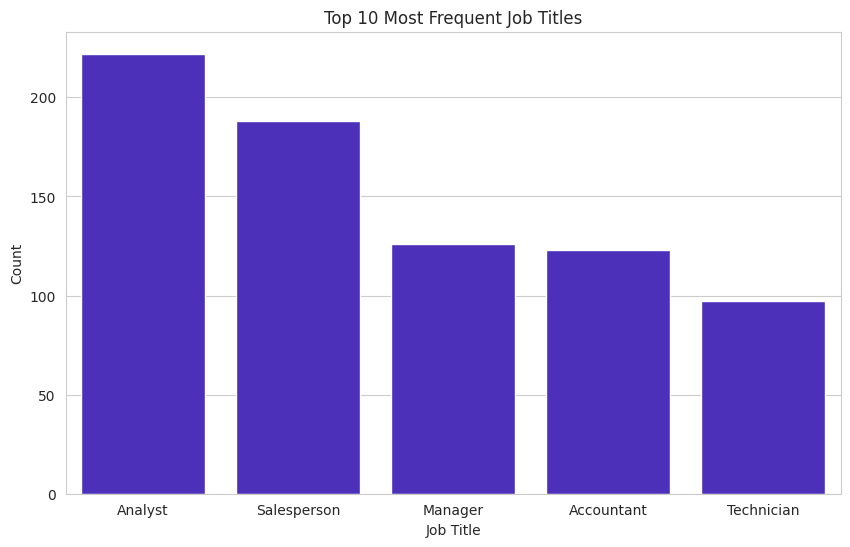

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(y=top_5.values, x=top_5.index,  color="#4019D1")

plt.title('Top 10 Most Frequent Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')

plt.show()

There are 43 job titles, the most common being "Analyst" and "Salesperson".

What are the highest average salaries for jobs?

In [50]:
top_salaries = df.groupby("job_title")["Salary"].mean().sort_values(ascending=False).head(10)
top_salaries

,Salary
job_title,
CEO,9312.500000
Developer,8357.142857
Doctor,8000.000000
Engineer,7291.900000
HR Specialist,6586.607143
Electrician,6513.636364
Pharmacist,6500.000000
Dentist,6250.000000
Artist,6012.333333


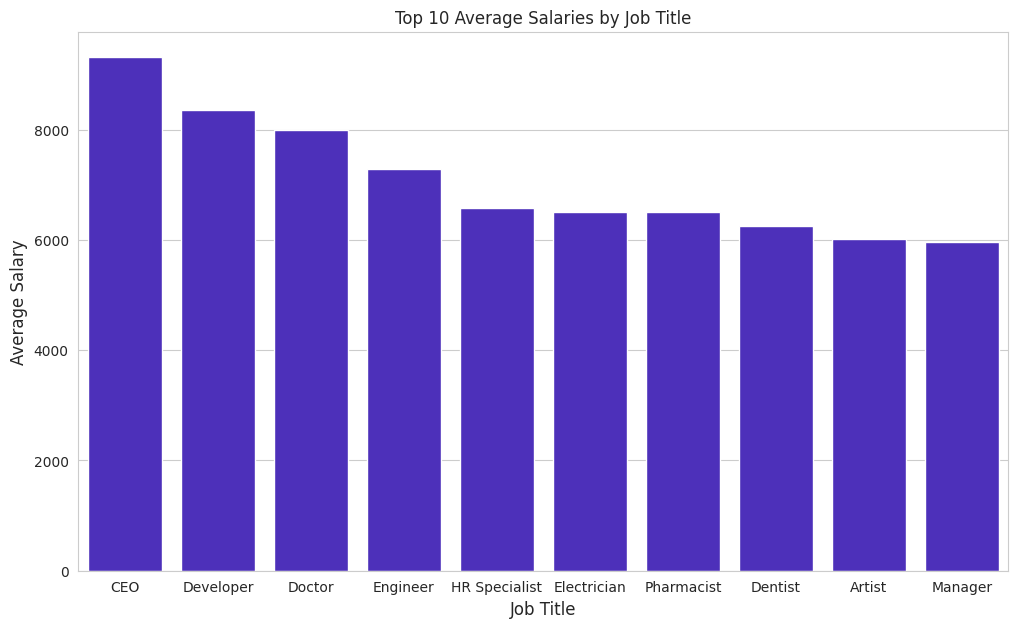

In [55]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(y=top_salaries.values, x=top_salaries.index , color="#4019D1" )

plt.title("Top 10 Average Salaries by Job Title")
plt.xlabel("Job Title", fontsize=12)
plt.ylabel("Average Salary", fontsize=12)

plt.show()

Highest average CEO salary




---
